# Figure 3: Variant assignment fitness comparison

In antigenic space -- with temproal fitness

## Import packages

In [5]:
import os
# Typing
from typing import Tuple, Optional
# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Bio.Phylo as bp
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

## Define helper functions

In [6]:
def calculate_fitness_of_tips(
    tips_df: pd.DataFrame, 
    host_coordinates: Tuple[float, float],
    ag1_col: str = 'ag1', 
    ag2_col: str = 'ag2',
    s: float = 0.07, 
    homologous_immunity: float = 0.95
) -> pd.DataFrame:
      """
      Calculate fitness of tips based on infection risk against 
  host coordinates.
      
      Parameters:
      - tips_df: DataFrame with ag1, ag2 columns
      - host_coordinates: tuple of (ag1, ag2) for host immune 
  memory
      - s: smith_conversion factor
      - homologous_immunity: float between 0 and 1
      
      Returns:
      - Copy of tips_df with added 'fitness' column
      """
      # Create a copy of the dataframe
      result_df = tips_df.copy()

      # Calculate Euclidean distance from each tip to host coordinates
      distances = ((tips_df[ag1_col] - host_coordinates[0])**2 +
                    (tips_df[ag2_col] - host_coordinates[1])**2)**0.5

      # Calculate risk of infection (equivalent to fitness in thiscontext)
      risk = distances * s
      min_risk = 1.0 - homologous_immunity
      risk = np.maximum(min_risk, risk)
      risk = np.minimum(1.0, risk)

      # Add fitness column
      result_df['fitness'] = risk

      return result_df

In [51]:
def plot_variant_assignments(df, variant_methods, var_assignment_scores_df=None, host_coordinates=None, 
                            t=None, figsize=(16, 5), fig_path=None, palette=None):
    """
    Plot variant assignments with points colored by variant, plus fitness landscape.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with ag1, ag2, fitness, and variant_* columns
    variant_methods : list of str
        List of variant column names to plot (e.g., ['variant_ag', 'variant_mds'])
    var_assignment_scores_df : pd.DataFrame, optional
        DataFrame with adjusted R² scores for each method and time point
    host_coordinates : tuple, optional
        (ag1, ag2) coordinates of host immunity centroid to plot as red X
    t : float, optional
        Time point for filtering var_assignment_scores_df
    figsize : tuple
        Figure size (width, height)
    fig_path : str, optional
        Path to save the figure (if None, figure is not saved)
    palette : list of str or dict, optional
        Color palette for variants. If list, colors assigned in order.
        If dict, maps variant labels to colors. If None, uses 'tab10' colormap.
    """
    n_methods = len(variant_methods) + 1  # +1 for fitness panel
    fig, axes = plt.subplots(1, n_methods, figsize=figsize, sharey=True)
    
    if n_methods == 1:
        axes = [axes]
    
    # Plot variant assignments
    for idx, method in enumerate(variant_methods):
        ax = axes[idx]
        
        # Get unique variants
        variants = sorted(df[method].unique())
        n_variants = len(variants)
        
        # Determine colors
        if palette is None:
            # Use tab10 colormap for up to 10 variants
            cmap = plt.cm.get_cmap('tab10')
            colors = [cmap(i % 10) for i in range(n_variants)]
        elif isinstance(palette, dict):
            colors = [palette.get(v, 'gray') for v in variants]
        else:
            colors = [palette[i % len(palette)] for i in range(n_variants)]
        
        # Create scatter plot for each variant with different color
        for i, variant in enumerate(variants):
            variant_data = df[df[method] == variant]
            
            ax.scatter(
                variant_data['ag1'], 
                variant_data['ag2'],
                c=[colors[i]],
                s=100,
                alpha=0.7,
                edgecolors='black'
            )
        
        # Plot host immunity centroid if provided
        if host_coordinates is not None:
            ax.plot(host_coordinates[0], host_coordinates[1], 'rx', 
                   markersize=15, markeredgewidth=3, label='Host Immunity')
        
        
        # Formatting
        ax.set_xlabel('ag1', fontsize=11, weight='600')
        if idx == 0:
            ax.set_ylabel('ag2', fontsize=11, weight='600')
        
        # Clean method name for title
        method_name = method.replace('variant_', '').lower()
        if method_name == 'ag' or method_name == 'variant':
            method_name = 'antigenic'
        ax.set_title(f'{method_name} variants', fontsize=12, weight='bold')

        # Add adjusted R² text if scores provided
        if var_assignment_scores_df is not None and t is not None:
            scores = var_assignment_scores_df[(var_assignment_scores_df['assignment_method'] == method_name) & 
                                             (var_assignment_scores_df['t'] == t)]
            if len(scores) > 0:
                adj_r2 = scores['adj_r2'].values[0]
                ax.text(0.05, 0.95, rf'$R^2$ = {adj_r2:.3f}', 
                       transform=ax.transAxes, fontsize=11, weight='bold',
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Remove top and right spines
        sns.despine(ax=ax)
    
    # Plot fitness landscape in last panel
    ax = axes[-1]
    scatter = ax.scatter(
        df['ag1'],
        df['ag2'],
        c=df['fitness'],
        cmap='RdBu',
        s=100,
        alpha=0.7,
        edgecolors='black',
        vmin=df['fitness'].min(),
        vmax=df['fitness'].max()
    )
    
    # Plot host immunity centroid if provided
    if host_coordinates is not None:
        ax.plot(host_coordinates[0], host_coordinates[1], 'rx', 
               markersize=15, markeredgewidth=3, label='Host Immunity')
    
    # Add colorbar for fitness
    cbar = plt.colorbar(scatter, ax=ax, label='Fitness')
    
    # Formatting
    ax.set_xlabel('ag1', fontsize=11, weight='600')
    ax.set_title('Fitness Landscape', fontsize=12, weight='bold')
    
    # Remove top and right spines
    sns.despine(ax=ax)
    
    plt.tight_layout()
    if fig_path is not None:
        plt.savefig(fig_path, dpi=300)
    plt.show()

## Load data

In [13]:
# Define data paths
build = 'flu-simulated-150k-samples-final'

# Output paths
fig_path = "../../antigen-tex/figures/"
out_path = f"../results/{build}/"

# Antigen outputs
tips_path = f"../data/{build}/tips_variant_assignment_compare.tsv"
histories_path = f"../data/{build}/antigen-outputs/histories.csv"

# Variant assignment scores
results_path = f"../results/{build}/variant_assignment_scores.tsv"

In [15]:
tips_df = pd.read_csv(tips_path, sep='\t')
print(f"Loaded {len(tips_df)} unique sequences from tips data")
histories_df = pd.read_csv(histories_path)
# In the bugged version, we recorded burnin. We need to remove those entries (year < 10) and then renumber years
histories_df = histories_df[histories_df['year'] >= 10].copy()
histories_df['year'] = histories_df['year'] - 10
print(f"Loaded {len(histories_df)} history entries after removing burnin")
var_assignment_scores_df = pd.read_csv(results_path, sep='\t')
print(f"Loaded variant assignment scores")

Loaded 5475 unique sequences from tips data
Loaded 120 history entries after removing burnin
Loaded variant assignment scores


## Plot a 5-year window

In [48]:
var_assignment_scores_df.head()

,t,assignment_method,bic,r2,adj_r2,n_clusters
0,5,antigenic,-4350.279567,0.937679,0.937364,6
1,5,mds,-3447.790743,0.866588,0.866027,5
2,5,pca,-3372.507830,0.858752,0.858039,6
3,5,tsne,-2730.451644,0.756838,0.755815,5
4,5,umap,-3410.312496,0.864764,0.863852,8


## Plot variant assignments

In [52]:
fig3_path = "../../antigen-tex/figures/variant_assignment_example.pdf"
methods_to_plot = ['variant_ag', 'variant_pca', 'variant_mds', 'variant_tsne', 'variant_umap']

In [53]:
# Try a 5-year window from t=17 to t=22
t = 22.0
snapshot_tips_df = tips_df[(tips_df['year'] >= (t - 5)) & (tips_df['year'] <= t)].copy()

# Recalculate fitness at t=22 with only data from last 5 years
total_hosts_df = histories_df.query(f"deme == 'total' and year == {t}")
host_coordinates = (total_hosts_df['ag1'].values[0], total_hosts_df['ag2'].values[0])

tips_fitness_df = calculate_fitness_of_tips(snapshot_tips_df, host_coordinates)

/var/folders/90/6t9_1yk52qd_sbpbmt4ym0540000gn/T/ipykernel_41124/2315435384.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


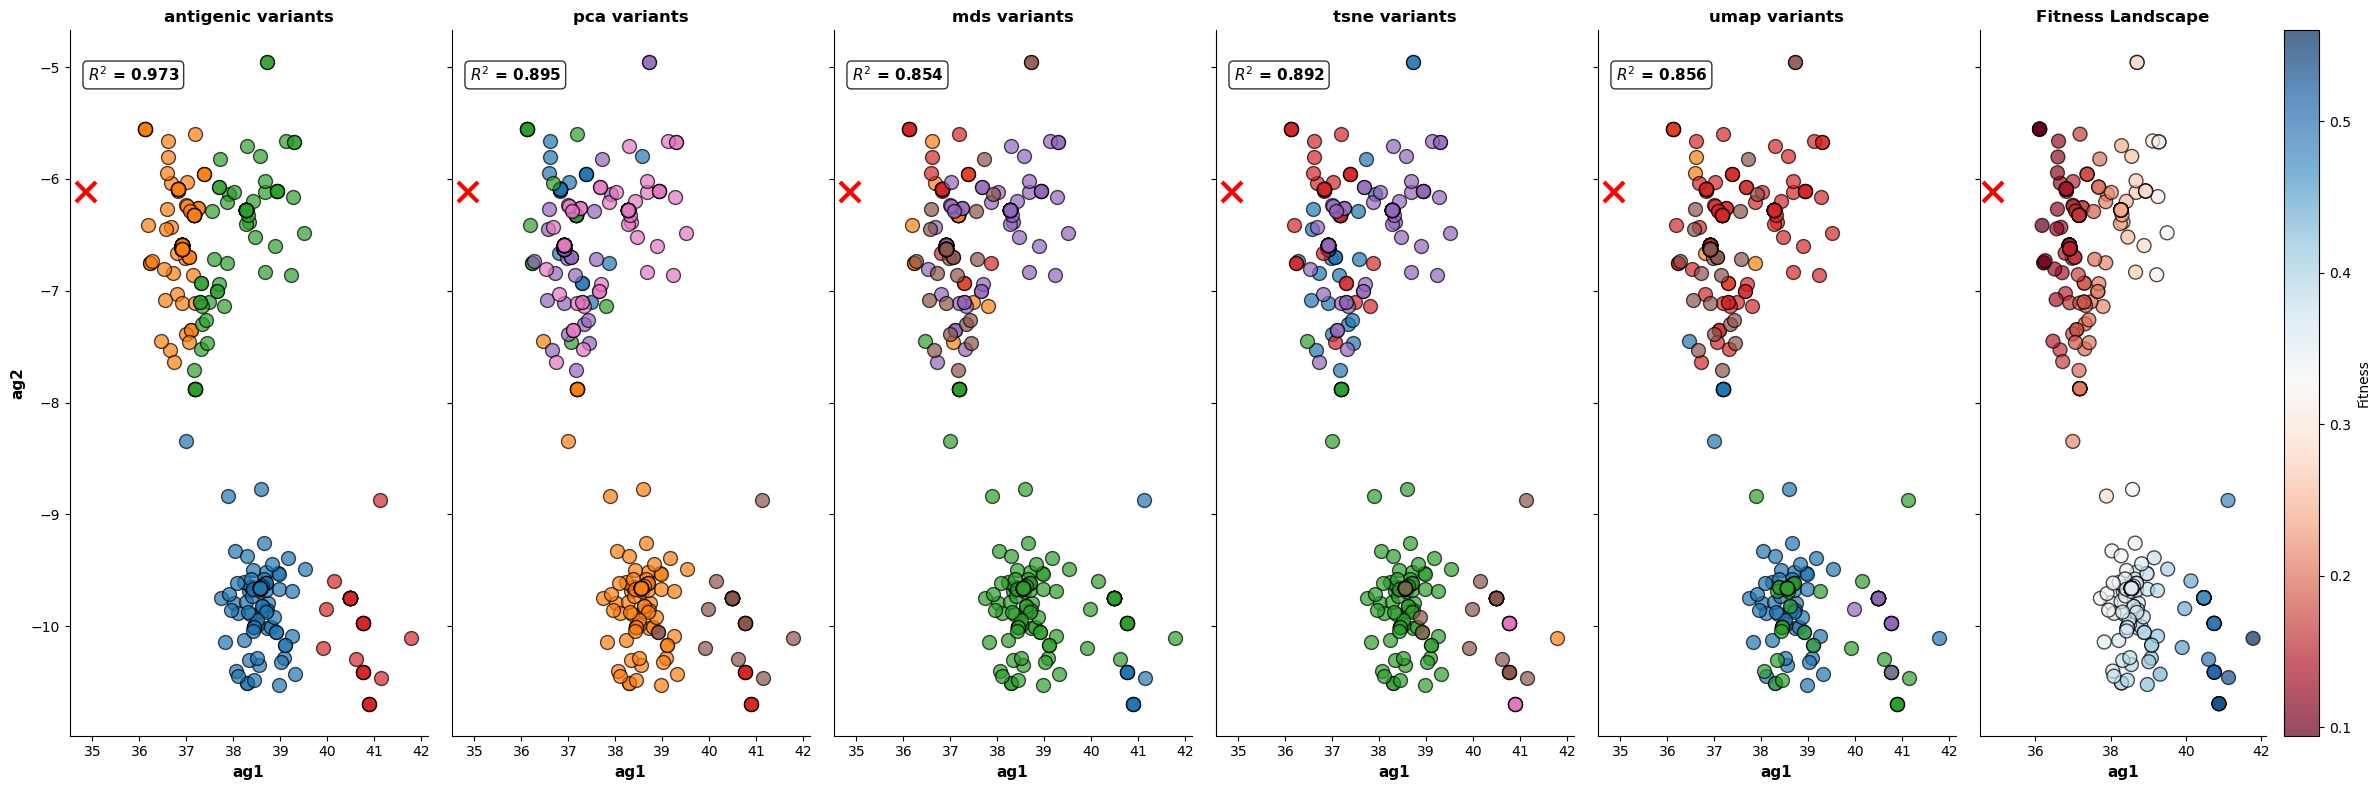

In [54]:
plot_variant_assignments(
    tips_fitness_df, 
    methods_to_plot, 
    var_assignment_scores_df=var_assignment_scores_df,
    host_coordinates=host_coordinates,
    t=t,
    figsize=(24, 8), 
    fig_path=fig3_path
)